In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("../data/raw/Sample - Superstore 2019.xlsx")

df.head()

c:\Users\MKamal\Desktop\superstore-2019-python-dashboard\.venv\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.shape

(9994, 21)

In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9994 non-null   int64         
 1   Order ID        9994 non-null   object        
 2   Order Date      9994 non-null   datetime64[ns]
 3   Ship Date       9994 non-null   datetime64[ns]
 4   Ship Mode       9994 non-null   object        
 5   Customer ID     9994 non-null   object        
 6   Customer Name   9994 non-null   object        
 7   Segment         9994 non-null   object        
 8   Country/Region  9994 non-null   object        
 9   City            9994 non-null   object        
 10  State           9994 non-null   object        
 11  Postal Code     9983 non-null   float64       
 12  Region          9994 non-null   object        
 13  Product ID      9994 non-null   object        
 14  Category        9994 non-null   object        
 15  Sub-

In [7]:
df.isnull().sum().sort_values(ascending=False)

Postal Code       11
Order ID           0
Order Date         0
Ship Date          0
Row ID             0
Ship Mode          0
Customer ID        0
Segment            0
Customer Name      0
Country/Region     0
City               0
State              0
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales              0
Quantity           0
Discount           0
Profit             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
kpis = {
    "Rows": len(df),
    "Columns": df.shape[1],
    "Unique Orders": df["Order ID"].nunique(),
    "Unique Customers": df["Customer ID"].nunique(),
    "Total Sales": df["Sales"].sum(),
    "Total Profit": df["Profit"].sum(),
    "Avg Discount": df["Discount"].mean(),
    "Loss Orders": (df["Profit"] < 0).sum(),
}
kpis

{'Rows': 9994,
 'Columns': 21,
 'Unique Orders': 5009,
 'Unique Customers': 793,
 'Total Sales': np.float64(2297200.8603),
 'Total Profit': np.float64(286397.0216999999),
 'Avg Discount': np.float64(0.1562027216329798),
 'Loss Orders': np.int64(1871)}

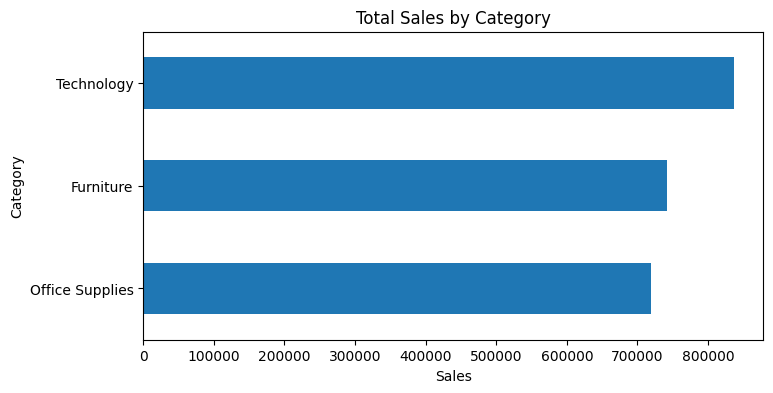

In [10]:
sales_by_category = df.groupby("Category")["Sales"].sum().sort_values()

sales_by_category.plot(kind="barh", figsize=(8,4))

plt.title("Total Sales by Category")
plt.xlabel("Sales")
plt.ylabel("Category")

plt.show()

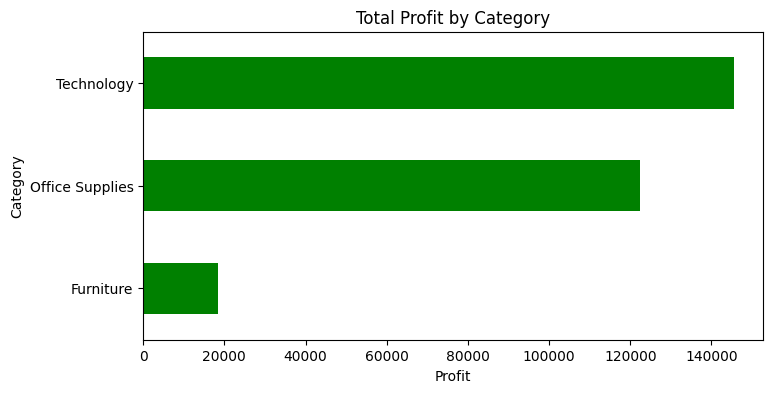

In [11]:
profit_by_category = df.groupby("Category")["Profit"].sum().sort_values()

profit_by_category.plot(kind="barh", figsize=(8,4), color="green")

plt.title("Total Profit by Category")
plt.xlabel("Profit")
plt.ylabel("Category")

plt.show()

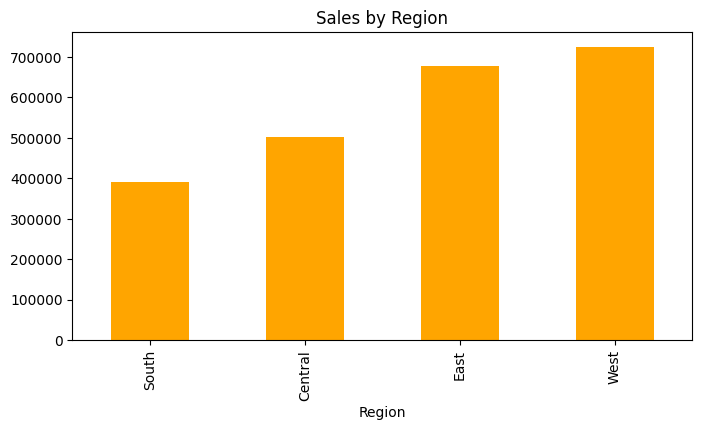

In [12]:
sales_by_region = df.groupby("Region")["Sales"].sum().sort_values()

sales_by_region.plot(kind="bar", figsize=(8,4), color="orange")

plt.title("Sales by Region")

plt.show()

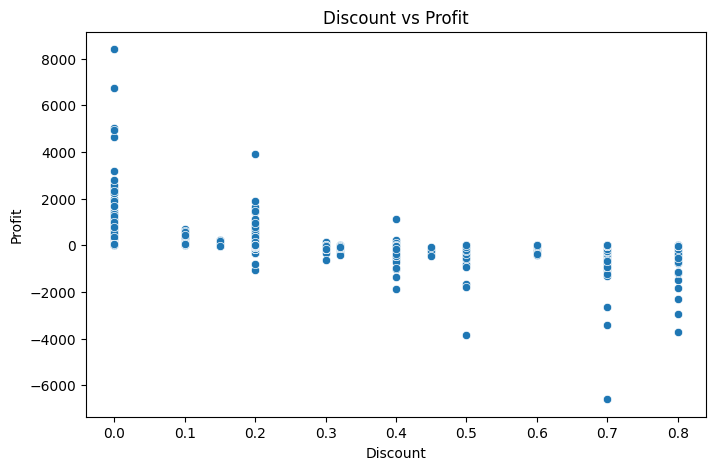

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="Discount", y="Profit")

plt.title("Discount vs Profit")

plt.show()

In [14]:
loss_subcat = (
    df.groupby("Sub-Category")["Profit"]
    .sum()
    .sort_values()
)

loss_subcat.head(10)

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Name: Profit, dtype: float64

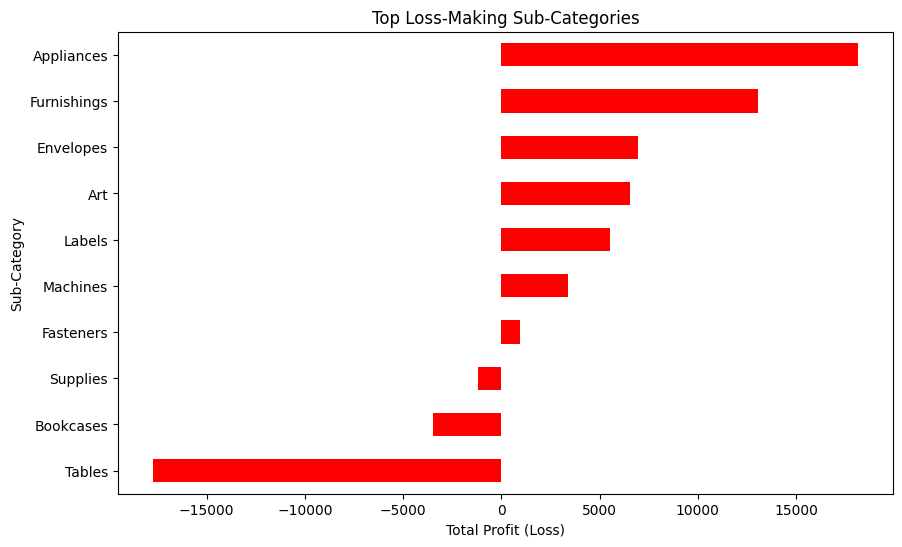

In [15]:
plt.figure(figsize=(10,6))

loss_subcat.head(10).plot(kind="barh", color="red")

plt.title("Top Loss-Making Sub-Categories")
plt.xlabel("Total Profit (Loss)")
plt.ylabel("Sub-Category")

plt.show()

In [16]:
top_sales_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_sales_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

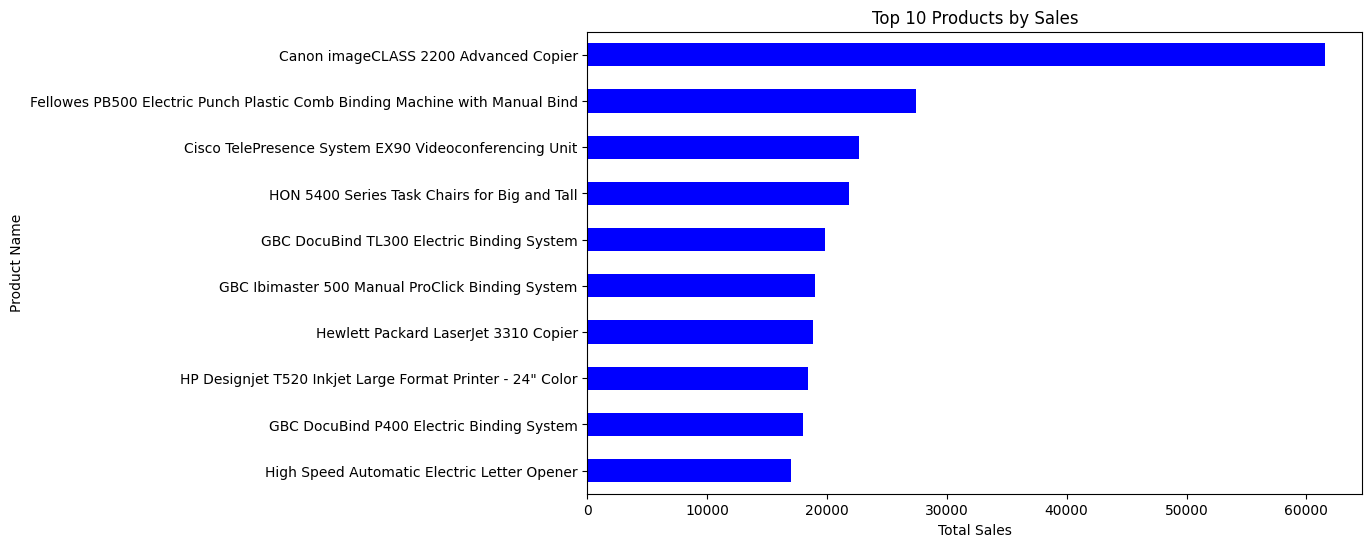

In [17]:
plt.figure(figsize=(10,6))

top_sales_products.sort_values().plot(kind="barh", color="blue")

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")

plt.show()

In [18]:
top_loss_products = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values()
    .head(10)
)

top_loss_products

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64

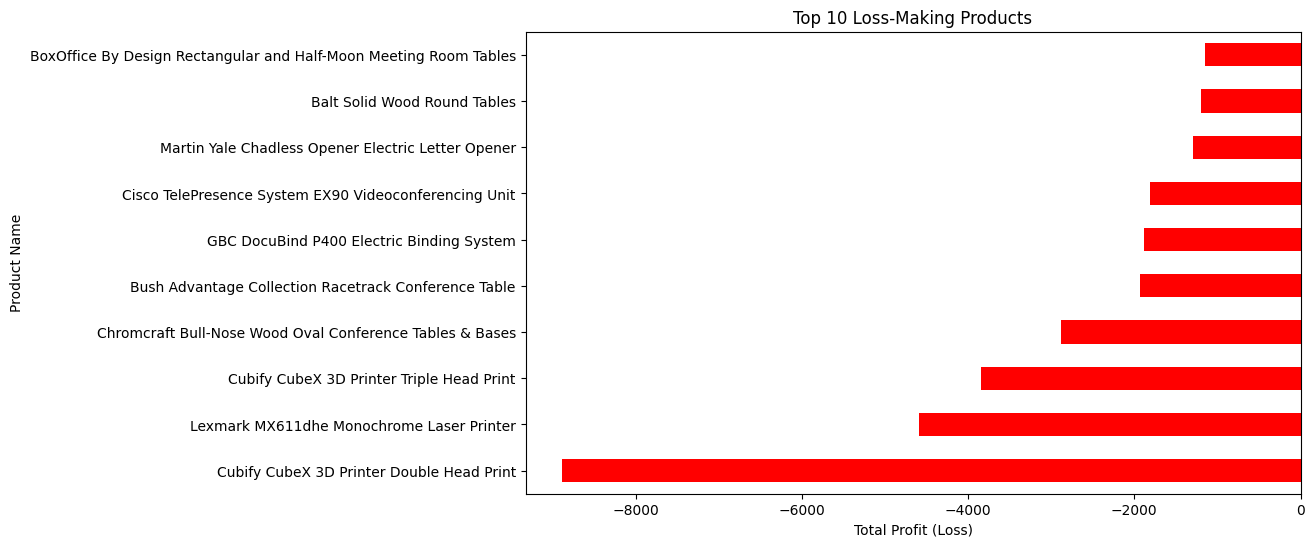

In [19]:
plt.figure(figsize=(10,6))

top_loss_products.plot(kind="barh", color="red")

plt.title("Top 10 Loss-Making Products")
plt.xlabel("Total Profit (Loss)")

plt.show()

In [20]:
discount_by_category = df.groupby("Category")["Discount"].mean()

discount_by_category

Category
Furniture          0.173923
Office Supplies    0.157285
Technology         0.132323
Name: Discount, dtype: float64

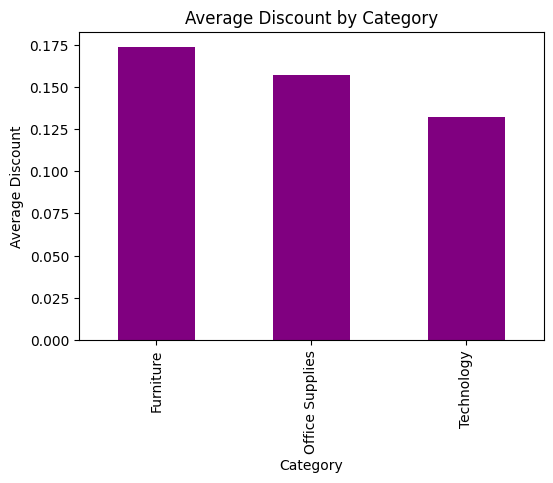

In [21]:
plt.figure(figsize=(6,4))

discount_by_category.plot(kind="bar", color="purple")

plt.title("Average Discount by Category")
plt.ylabel("Average Discount")

plt.show()